In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
  tarball_path = Path('datasets/housing.tgz') #looks for the file to see if it's there
  if not tarball_path.is_file(): #if not, run this
    Path("datasets").mkdir(parents = True,exist_ok= True) #make a folder
    url = "https://github.com/ageron/data/raw/main/housing.tgz" #url containing the dataset
    urllib.request.urlretrieve(url,tarball_path) #install the dataset and put it in the tarball path
    with tarfile.open(tarball_path) as housing_tarball: #open the file
      housing_tarball.extractall(path="datasets",filter="data") #unzip or in this case extract the tar file
  return pd.read_csv(Path("datasets/housing/housing.csv")) #return the file




housing = load_housing_data()


In [28]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [29]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [30]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [31]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


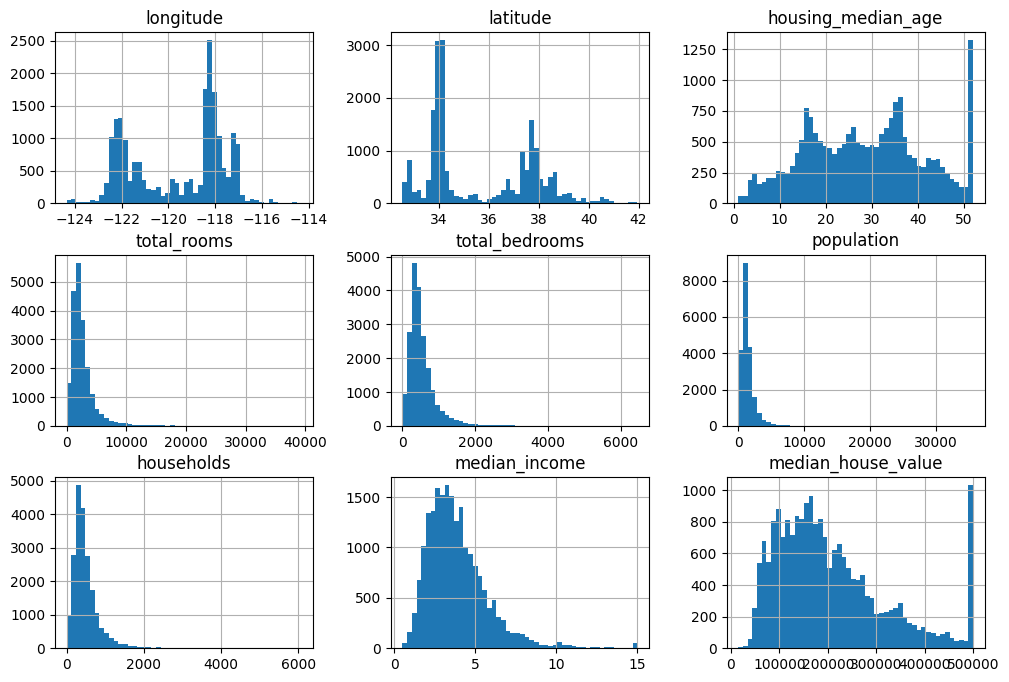

In [32]:
import matplotlib.pyplot as plt
housing.hist(bins = 50,figsize = (12,8)) #bins are the amount of equal intervals
# we want to have e.g(bins = 2 is like 0-10,10-20 assuming the range of the data is 0-20)
# figsize is simply the size of the "canvas" for our plot'''
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
train_set , test_set = train_test_split(housing,test_size=0.2,random_state=42)
#test_size = Size of the test dataset, that means the size would be
#80% training and 20% test
#random_state = to make sure the data is split the same way every time to prevent
#the model from "cheating" by looking at the entire dataset (it's called
 #data snooping bias)

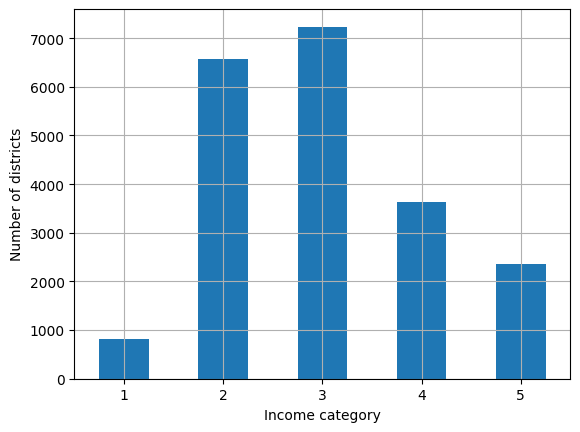

In [34]:
housing["income_cat"] = pd.cut(housing["median_income"],bins=[0,1.5,3.0,4.5,6,np.inf],labels=[1,2,3,4,5])
# bins = interval of the data ,
#labels = the group/strata of each interval
#e.g (0-1.5) belongs to strata/label 1
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid = True) #using bar chart
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [35]:
strat_train_set , strat_test_set = train_test_split(housing,test_size = 0.2,stratify=housing["income_cat"] ,random_state = 42)
#to do stratified sampling we simply use train_test_split with stratify parameter

strat_train_set = strat_train_set.drop("income_cat",axis=1)
strat_test_set = strat_test_set.drop("income_cat",axis=1)

#Dropping the income_cat feature beccause it serves no use now

print(strat_train_set.head())
print(strat_test_set.head())






       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  
13096        NEAR BAY  
14973       <1H OCEAN  
3785           INLAND  
14689          INLAN

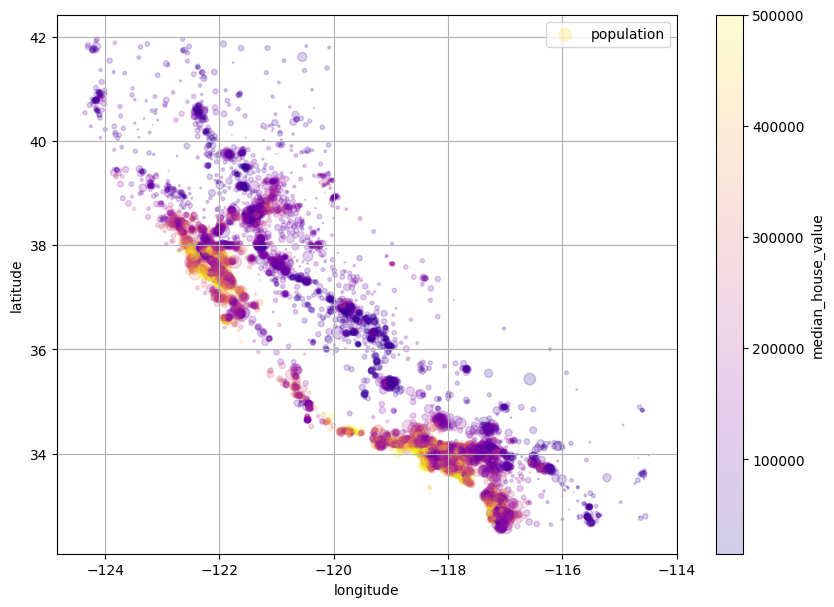

In [36]:
housing = strat_train_set.copy() #copying the training set for convenience
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2,s=housing["population"]/100,label="population",c="median_house_value",cmap="plasma",colorbar=True,legend=True,sharex=False,figsize=(10,7))
#Explanation of each parameters in the plot function:
#kind = What kind of plot we want, in this case we use scatterplot
#x , y = the vertical and horizontal axes
#grid = Add a grid overlay
#alpha = transparency/opacity so we can see the scatterplot clearly
 #s = the size of the scatterplot points, we divide it by 100 so we can see it better
# label = adding a label to indicate what the points are
 #c = The value we want to use for the colormap
 #cmap = range of colors to map numerical value, there are many cmap color sets for this one I used plasma
 #legend = adding a small box in the top right corner to display the label
 #sharex = to make the subplots share the x axes, it doesn't matter here
 #figsize = the size of the canvas
plt.show()

In [37]:
corr_matrix = housing.corr(numeric_only = True)
#Our data has categorical feature so set numeric_only to true
print(corr_matrix["median_house_value"].sort_values(ascending=False))
#We want to see how other features correlate with median_house_value

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


In [38]:


housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only = True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))


median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64


In [39]:
housing_label = housing[['median_house_value']].copy()
housing = housing.drop('median_house_value',axis =1)

In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
#Replace missing values with the strategy parameter in this case median
housing_num = housing.select_dtypes(include=['number'])
#Include only numerical features
imputer.fit(housing_num)
#Fitting the imputer to specific features
X = imputer.transform(housing_num)
#Replace/ impute the missing values with median

In [41]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
index=housing_num.index)
#columns = getting the column names back
#index = identifier for each row like SQL primary key'''
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   rooms_per_house     16512 non-null  float64
 9   bedrooms_ratio      16512 non-null  float64
 10  people_per_house    16512 non-null  float64
dtypes: float64(11)
memory usage: 1.5 MB


In [42]:
from sklearn.preprocessing import OrdinalEncoder
housing_cat = housing.select_dtypes(include = ['object'])
print(housing_cat.head())
encoder = OrdinalEncoder()
encoder.fit(housing_cat)
housing_cat_encoded = encoder.transform(housing_cat)
housing_cat_encoded = pd.DataFrame(housing_cat_encoded,columns = housing_cat.columns,
                                   index=housing_cat.index)
print(housing_cat_encoded.head())
print(encoder.categories_)


      ocean_proximity
13096        NEAR BAY
14973       <1H OCEAN
3785           INLAND
14689          INLAND
20507      NEAR OCEAN
       ocean_proximity
13096              3.0
14973              0.0
3785               1.0
14689              1.0
20507              4.0
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [43]:
from sklearn.preprocessing import OneHotEncoder
encoder2 = OneHotEncoder()
encoder2.fit(housing_cat)
housing_cat_1hot = encoder2.transform(housing_cat)
print(housing_cat_1hot)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>
  Coords	Values
  (0, 3)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 4)	1.0
  (5, 1)	1.0
  (6, 0)	1.0
  (7, 3)	1.0
  (8, 0)	1.0
  (9, 0)	1.0
  (10, 1)	1.0
  (11, 0)	1.0
  (12, 0)	1.0
  (13, 1)	1.0
  (14, 4)	1.0
  (15, 0)	1.0
  (16, 1)	1.0
  (17, 3)	1.0
  (18, 1)	1.0
  (19, 0)	1.0
  (20, 0)	1.0
  (21, 4)	1.0
  (22, 1)	1.0
  (23, 3)	1.0
  (24, 1)	1.0
  :	:
  (16487, 1)	1.0
  (16488, 0)	1.0
  (16489, 0)	1.0
  (16490, 3)	1.0
  (16491, 1)	1.0
  (16492, 4)	1.0
  (16493, 4)	1.0
  (16494, 1)	1.0
  (16495, 0)	1.0
  (16496, 1)	1.0
  (16497, 0)	1.0
  (16498, 0)	1.0
  (16499, 4)	1.0
  (16500, 0)	1.0
  (16501, 0)	1.0
  (16502, 0)	1.0
  (16503, 0)	1.0
  (16504, 0)	1.0
  (16505, 0)	1.0
  (16506, 1)	1.0
  (16507, 0)	1.0
  (16508, 1)	1.0
  (16509, 4)	1.0
  (16510, 0)	1.0
  (16511, 4)	1.0


In [44]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [45]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num_min_max_scaled = pd.DataFrame(housing_num_min_max_scaled,columns=housing_num.columns,index=housing_num.index)
print(housing_num_min_max_scaled.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096  -0.608519  0.117021            1.000000    -0.831171       -0.641166   
14973   0.210953 -0.661702            0.529412    -0.900148       -0.886294   
3785   -0.519270  0.236170            0.254902    -0.945012       -0.930424   
14689   0.468560 -0.744681           -0.372549    -0.787782       -0.726204   
20507   0.257606 -0.740426            0.372549    -0.778015       -0.610243   

       population  households  median_income  rooms_per_house  bedrooms_ratio  \
13096   -0.807018   -0.614336      -0.779479        -0.967056       -0.476128   
14973   -0.918660   -0.867090      -0.229293        -0.934544       -0.821883   
3785    -0.931419   -0.924585      -0.733369        -0.936944       -0.776957   
14689   -0.774015   -0.709166      -0.756983        -0.936713       -0.769153   
20507   -0.765796   -0.562815      -0.582171        -0.959774       -0.605843   

       people_per_house  
13096       

In [46]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
housing_num_std_scaled = standard_scaler.fit_transform(housing_num)
housing_num_std_scaled = pd.DataFrame(housing_num_std_scaled,columns=housing_num.columns,index=housing_num.index)
print(housing_num_std_scaled.head())



       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096  -1.423037  1.013606            1.861119     0.311912        1.359094   
14973   0.596394 -0.702103            0.907630    -0.308620       -0.436356   
3785   -1.203098  1.276119            0.351428    -0.712240       -0.759584   
14689   1.231216 -0.884924           -0.919891     0.702262        0.736231   
20507   0.711362 -0.875549            0.589800     0.790125        1.585590   

       population  households  median_income  rooms_per_house  bedrooms_ratio  \
13096    0.137460    1.394812      -0.936491        -0.866027        2.141352   
14973   -0.693771   -0.373485       1.171942         0.024550       -0.568545   
3785    -0.788768   -0.775727      -0.759789        -0.041193       -0.216432   
14689    0.383175    0.731375      -0.850281        -0.034858       -0.155267   
20507    0.444376    1.755263      -0.180365        -0.666554        1.124695   

       people_per_house  
13096       

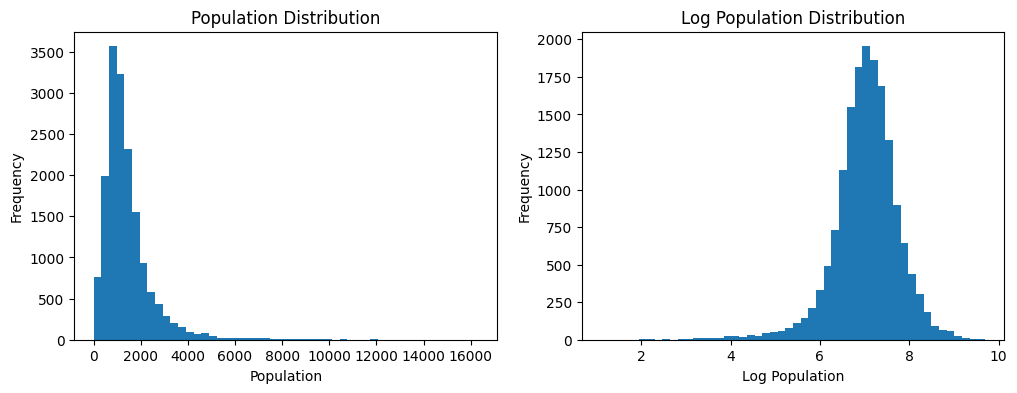

In [47]:
population = housing_num['population']
log_population = np.log(population)
fig , ax = plt.subplots(1,2,figsize=(12,4))
#subplots will return a 1d array if it's just one row
ax[0].hist(population,bins=50)
ax[0].set_xlabel("Population")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Population Distribution")
ax[1].hist(log_population,bins=50)
ax[1].set_xlabel("Log Population")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Log Population Distribution")
plt.show()

In [48]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35 = rbf_kernel(housing_num[['housing_median_age']],[[35]],gamma=0.1)
print(age_simil_35[:5])

[[2.81118530e-13]
 [8.20849986e-02]
 [6.70320046e-01]
 [8.48904403e-15]
 [9.04837418e-01]]


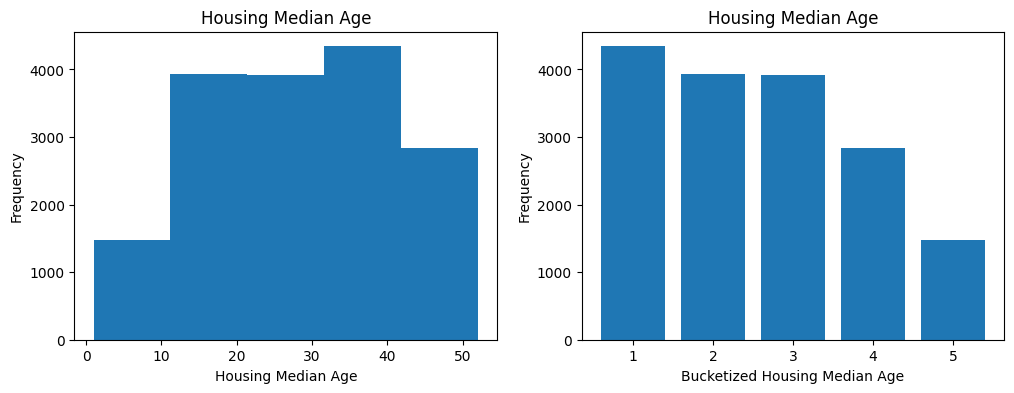

In [50]:
bucketized_housing_age = pd.cut(housing_num['housing_median_age'],bins = 5,labels=[1,2,3,4,5])
fig , ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(housing_num['housing_median_age'],bins=5)
ax[0].set_xlabel("Housing Median Age")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Housing Median Age")
ax[1].bar(bucketized_housing_age.value_counts().sort_index().index,bucketized_housing_age.value_counts())
ax[1].set_xlabel("Bucketized Housing Median Age")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Housing Median Age")
plt.show()